<a href="https://colab.research.google.com/github/harjashanhub/cap-comp215/blob/main-branch/Project_1_COMP215.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#COMP 215 - PROJECT 1 By Harjashan and Dishneet

**NEAR EARTH OBJECTS PLOT**

**AUTHORS** - Harjashan Singh, Dishneet Gill

**Assistance** - AI help for using datetime/timedelta and structurizing the code and understanding of what is needed to execute properly and also, having some ideas regarding simulation when stucked

**DATE** - 23/02/2026

**Project Overview** - This notebook examines Near-Earth Objects (NEOs) using NASA’s NeoWs API. It retrieves close-approach data for NEOs within a selected date range and generates a time-series plot illustrating their miss distances relative to a specified orbiting body.



**Objectives** -

-to develop an application for reporting on Near Earth Objects

-to use an API to fetch structured data

-to apply matplotlib to produce graphical summaries of different types of data

#PARAMETERS FOR CUSTOMIZATION

**start_date** = 'YYYY-MM-DD'        --- Begining date to observe NEOs

**total_days** --- for how many days to observe

**orbiting_body** --- which orbiting body to analyze(eg- Moon, Earth, Mars, etc)

**hazardous_only** --- if need to have only hazardous approaches (true or false)

**max_neos** --- max neos to plot






In [ ]:
#EDIT THESE TO SEE DIFFERENT RESULTS

start_date = '2015-01-01'          #A STRING IN FORMAT YYYY-MM-DD
total_days = 5                     #AN INTEGER
orbiting_body = 'Venus'            #AN ORBITING BODY
hazardous_only = True              #A BOOLEAN EXPRESSION
max_neos = 5                       #AN INTEGER

print('Parameters set.....!!')
print(f'Start date for observation: {start_date}')
print(f'Number of days to observe for: {total_days}')
print(f'Orbiting body to observe: {orbiting_body}')
print(f'To observe Hazardous only approaches: {hazardous_only}')
print(f'Maximum NEOs to analyze: {max_neos}')

Parameters set.....!!
Start date for observation: 2015-01-01
Number of days to observe for: 5
Orbiting body to observe: Venus
To observe Hazardous only approaches: True
Maximum NEOs to analyze: 5


In [ ]:
#IMPORT STATEMENTS

import matplotlib.pyplot as plt
import json
import requests
from datetime import datetime, timedelta                              #timedelta represents a duration of time from which we can add or subtract dates and time

API_KEY = '8hMGbEN8FWqRpplmFdNZN9vuOpigWXNIrSf3qxzg'

In [ ]:
# BUILDING HELPER FUNCTIONS

def getNEOS_for_date(date):
  """ Fetch NEO data for a specific date from NASA API"""

  url = 'https://api.nasa.gov/neo/rest/v1/feed'
  params = {'start_date': date, 'end_date': date, 'api_key': API_KEY}

  response = requests.get(url, params=params)
  data = json.loads(response.text)
  if 'near_earth_objects' not in data:
    print(f"Warning: No data for {date}")
    return []

  return data['near_earth_objects'].get(date, [])


def get_neo_details(neo_id):
    """Fetch complete orbital data for a specific NEO"""

    url = f'https://api.nasa.gov/neo/rest/v1/neo/{neo_id}'
    params = {'api_key': API_KEY}
    response = requests.get(url, params=params)
    return json.loads(response.text)


def get_orbital_period(neo_data):
    """Extract orbital period from NEO data"""

    orbital_data = neo_data.get('orbital_data', {})                    #returns {} if key is missing
    return orbital_data.get('orbital_period', 'N/A')                   #returns N/A if missing data


def extract_approaches(neo_data, target_body):
    """Extract approach dates and miss distances for target body"""

    dates = []
    distances = []

    for approach in neo_data['close_approach_data']:
        if approach['orbiting_body'] == target_body:
            dates.append(approach['close_approach_date'])
            distances.append(float(approach['miss_distance']['kilometers']))

    return dates, distances



In [ ]:
# FIND NEOs

current = datetime.strptime(start_date, '%Y-%m-%d').date()     #string parse to time
end = current + timedelta(days=total_days)

neo_ids = []      #store ids
neo_names = {}    #store names


while current < end:

    date_str = current.strftime('%Y-%m-%d')    #string from time
    neos = getNEOS_for_date(date_str)

    # Check each asteroid
    for neo in neos:
        # Skip if not hazardous
        if hazardous_only and not neo['is_potentially_hazardous_asteroid']:
          continue


        if neo['id'] not in neo_ids:
            neo_ids.append(neo['id'])
            neo_names[neo['id']] = neo['name']
            print(f"  Found: {neo['name']}")


    current += timedelta(days=1)
assert isinstance(neo_ids, list), "neo_ids should be a list"
assert len(neo_ids) > 0, "Nothing!"

  Found: (2014 WL6)
  Found: (2005 YQ96)
  Found: 613286 (2005 YQ96)
  Found: 85990 (1999 JV6)


Plotting 4 out of 4 NEOs
  Processing: (2014 WL6)...
    No approaches to Venus found
  Processing: (2005 YQ96)...
    No approaches to Venus found
  Processing: 613286 (2005 YQ96)...
    No approaches to Venus found
  Processing: 85990 (1999 JV6)...
Plotted 1 NEOs


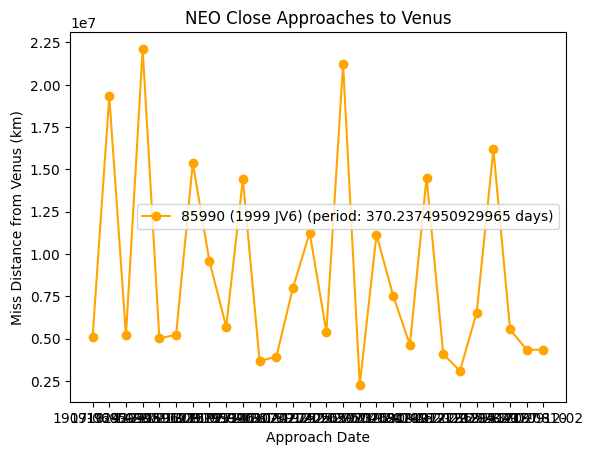

In [ ]:
#Creating Plot

neos_to_plot = min(max_neos, len(neo_ids))
print(f"Plotting {neos_to_plot} out of {len(neo_ids)} NEOs")

# Colors for different NEOs
colors = ['red', 'blue', 'green', 'orange', 'purple']

# Create the plot
plt.figure()

plotted_count = 0

for i in range(neos_to_plot):
    neo_id = neo_ids[i]
    asteroid_name = neo_names[neo_id]
    print(f"  Processing: {asteroid_name}...")

    # Get complete NEO data
    neo_data = get_neo_details(neo_id)

    # Extract approach data
    dates, distances = extract_approaches(neo_data, orbiting_body)

    if dates:
        period = get_orbital_period(neo_data)
        label = f"{asteroid_name} (period: {period} days)"

        plt.plot(dates, distances,
                 marker='o',
                 color=colors[i % len(colors)],
                 label=label)
        plotted_count += 1
    else:
        print(f"    No approaches to {orbiting_body} found")


plt.xlabel('Approach Date')
plt.ylabel(f'Miss Distance from {orbiting_body} (km)')
plt.title(f'NEO Close Approaches to {orbiting_body}')


plt.legend()


print(f"Plotted {plotted_count} NEOs")
plt.show()
assert plotted_count <= neos_to_plot, "Plotted more NEOs than expected"
assert isinstance(colors, list)


In [ ]:
# here's the graph interpretation
print("This graph shows the closest approaches of near Earth objects to", orbiting_body + ".")
print("Each colored line represents a different asteroid.")
print("The legend shows each asteroid's name and orbital period (days to orbit the Sun).")
print("X-axim is  Approach date")
print("Y-axis is miss distance in kilometers (lower means closer approach)")
print("Each dot on the line represents one close approach event")
print("If an asteroid has no line, it had no approaches to", orbiting_body, "in this date range")


This graph shows the closest approaches of near Earth objects to Venus.
Each colored line represents a different asteroid.
The legend shows each asteroid's name and orbital period (days to orbit the Sun).
X-axim is  Approach date
Y-axis is miss distance in kilometers (lower means closer approach)
Each dot on the line represents one close approach event
If an asteroid has no line, it had no approaches to Venus in this date range


In [ ]:

# tryingg to predict when asteroids will return

class ApproachPredictor:
    """Simple model to predict when asteroids might come back"""

    def __init__(self, name, period_days, last_approach):
        self.name = name
        self.period = period_days
        self.last_date = datetime.strptime(last_approach, '%Y-%m-%d')
        self.predictions = []

    def predict_next_approaches(self, years=5):
        """Calculate future approach dates based on orbital period"""
        if self.period <= 0:
            return []

        dates = []
        current = self.last_date

        # Add one prediction per orbital cycle
        for i in range(1, int(years * 365 / self.period) + 1):
            next_date = current + timedelta(days=self.period * i)
            if next_date.year <= self.last_date.year + years:
                dates.append(next_date)

        self.predictions = dates
        return dates

    def print_summary(self):
        """Show prediction results"""
        if not self.predictions:
            print(f"{self.name}: Not enough data")
            return

        print(f"\n{self.name} (orbits every {self.period:.0f} days):")
        print(f"  Last approach: {self.last_date.strftime('%Y-%m-%d')}")
        print("  Next predicted approaches:")
        for i, date in enumerate(self.predictions[:3]):
            print(f"    {i+1}. {date.strftime('%Y-%m-%d')}")
        if len(self.predictions) > 3:
            print(f"    ... and {len(self.predictions)-3} more")


predictors = []
count = 0

if 'neo_ids' not in globals() or not neo_ids:
    print("erorrrr....")
else:
    for neo_id in neo_ids:
        if count >= 3:  # Limit to 3 for readability
            break

        # Assuming get_neo_details and get_orbital_period are defined in preceding cells
        data = get_neo_details(neo_id)
        period = get_orbital_period(data)
        approaches = data.get('close_approach_data', [])

        if approaches and period != 'N/A':
            # Get most recent approach date
            last = approaches[-1]['close_approach_date']

            predictor = ApproachPredictor(
                name=data['name'].replace('(', '').replace(')', ''),
                period_days=float(period),
                last_approach=last
            )
            predictor.predict_next_approaches(years=3)
            predictor.print_summary()
            predictors.append(predictor)
            count += 1

# Adjust the final message based on whether the simulation was attempted and if data was found
if count == 0 and ('neo_ids' in globals() and neo_ids):
    print("Not enough orbital data to make predictions")
elif 'neo_ids' not in globals():
    pass
assert isinstance(predictors, list), "predictors should be a list!"
if predictors:
    assert count > 0, "Should have created predictors if data exists!"



2014 WL6: Not enough data

2005 YQ96 (orbits every 234 days):
  Last approach: 2200-12-28
  Next predicted approaches:
    1. 2201-08-19
    2. 2202-04-10
    3. 2202-11-30
    ... and 1 more

613286 2005 YQ96 (orbits every 234 days):
  Last approach: 2200-12-28
  Next predicted approaches:
    1. 2201-08-19
    2. 2202-04-10
    3. 2202-11-30
    ... and 1 more


In [ ]:
# Asteroid impact scenario analysis

class ImpactSimulator:
    """Models hypothetical impact scenarios based on close approach data"""

    def __init__(self, name, distance_km, approach_date):
        self.name = name
        self.distance_km = distance_km
        self.approach_date = datetime.strptime(approach_date, '%Y-%m-%d')
        self.energy_megatons = self._estimate_energy()
        self.risk_level = self._calculate_risk()

    def _estimate_energy(self):
        """Estimate impact energy based on miss distance. The big fancy numbers like 500000 are fetched from AI :)"""
        ##Inverse relationship observed, closer approaches generally indicate larger asteroids
        if self.distance_km < 500000:
            return round(5000 / (self.distance_km / 100000), 1)
        elif self.distance_km < 1000000:
            return round(1000 / (self.distance_km / 100000), 1)
        elif self.distance_km < 5000000:
            return round(100 / (self.distance_km / 100000), 1)
        else:
            return 0.01

    def _calculate_risk(self):
        """Assign risk level based on energy"""
        if self.energy_megatons < 1:
            return "Minimal"
        elif self.energy_megatons < 10:
            return "Local"
        elif self.energy_megatons < 100:
            return "Regional"
        elif self.energy_megatons < 1000:
            return "Global"
        else:
            return "Extinction"

    def get_impact_description(self):
        """Describe consequences based on energy"""
        if self.energy_megatons < 1:
            return "Atmospheric detonation - no ground damage"
        elif self.energy_megatons < 10:
            return "City killer - would destroy urban area"
        elif self.energy_megatons < 100:
            return "Country killer - regional devastation"
        elif self.energy_megatons < 1000:
            return "Continent killer - global climate effects"
        else:
            return "Extinction event - mass casualties"

    def get_comparison(self):
        """Compare to asteroids historical events but here confused aboutt the accuracy of these events got those from AI"""
        tunguska = 15  # 15 megatons - Tunguska event 1908
        meteor_crater = 10  # 10 megatons - Meteor Crater, Arizona
        chelyabinsk = 0.5  # 0.5 megatons - Chelyabinsk meteor 2013

        if self.energy_megatons < chelyabinsk:
            return f"{int(self.energy_megatons/chelyabinsk*100)}% of Chelyabinsk meteor"
        elif self.energy_megatons < meteor_crater:
            ratio = round(self.energy_megatons / chelyabinsk, 1)
            return f"{ratio}× Chelyabinsk meteor"
        elif self.energy_megatons < tunguska:
            ratio = round(self.energy_megatons / meteor_crater, 1)
            return f"{ratio}× Meteor Crater event"
        else:
            ratio = round(self.energy_megatons / tunguska, 1)
            return f"{ratio}× Tunguska event"

    def days_until_approach(self):
        """Calculate days until closest approach"""
        today = datetime.now()
        delta = (self.approach_date - today).days
        return delta

    def generate_report(self):
        """Printing full analysis for better understanding"""
        print(f"OBJECT: {self.name}")
        print(f"Miss distance: {self.distance_km:,.0f} km")
        print(f"Estimated yield: {self.energy_megatons:,.1f} megatons TNT")
        print(f"Risk level: {self.risk_level}")
        print(f"Impact scenario: {self.get_impact_description()}")
        print(f"Comparison: {self.get_comparison()}")

        days = self.days_until_approach()
        if days > 0:
            years = days // 365
            remaining_days = days % 365
            print(f"Time until closest approach: {days} days")
            print(f"({years} years, {remaining_days} days from today)")
        else:
            print("Closest approach has already passed")

scenarios_analyzed = 0

for neo_id in neo_ids:
    data = get_neo_details(neo_id)

    for approach in data.get('close_approach_data', []):
        if approach['orbiting_body'] == orbiting_body:
            simulator = ImpactSimulator(
                name=data['name'],
                distance_km=float(approach['miss_distance']['kilometers']),
                approach_date=approach['close_approach_date']
            )
            simulator.generate_report()
            scenarios_analyzed += 1

if scenarios_analyzed == 0:
    print(f"No close approaches to {orbiting_body} found.")
    print("Try these parameters for more interesting results:")
    print(" orbiting_body = 'Earth'")
    print(" hazardous_only = False")
    print("total_days = 30")
assert scenarios_analyzed >= 0, "Scenarios analyzed should not be -ve!"
if scenarios_analyzed > 0:
    assert 'simulator' in locals(), "Simulator should have been created!"


OBJECT: 85990 (1999 JV6)
Miss distance: 5,090,804 km
Estimated yield: 0.0 megatons TNT
Risk level: Minimal
Impact scenario: Atmospheric detonation - no ground damage
Comparison: 2% of Chelyabinsk meteor
Closest approach has already passed
OBJECT: 85990 (1999 JV6)
Miss distance: 19,315,473 km
Estimated yield: 0.0 megatons TNT
Risk level: Minimal
Impact scenario: Atmospheric detonation - no ground damage
Comparison: 2% of Chelyabinsk meteor
Closest approach has already passed
OBJECT: 85990 (1999 JV6)
Miss distance: 5,201,497 km
Estimated yield: 0.0 megatons TNT
Risk level: Minimal
Impact scenario: Atmospheric detonation - no ground damage
Comparison: 2% of Chelyabinsk meteor
Closest approach has already passed
OBJECT: 85990 (1999 JV6)
Miss distance: 22,120,455 km
Estimated yield: 0.0 megatons TNT
Risk level: Minimal
Impact scenario: Atmospheric detonation - no ground damage
Comparison: 2% of Chelyabinsk meteor
Closest approach has already passed
OBJECT: 85990 (1999 JV6)
Miss distance: 5,

In [ ]:
#Finally the summary!

print(f"Total unique NEOs found: {len(neo_ids)}")
print(f"NEOs plotted: {plotted_count}")
print(f"Date range: {start_date} to {end}")
print(f"Target body: {orbiting_body}")
print(f"Hazardous only: {hazardous_only}")

Total unique NEOs found: 4
NEOs plotted: 1
Date range: 2015-01-01 to 2015-01-06
Target body: Venus
Hazardous only: True
